In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/deeplearning_study')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.config.list_physical_devices('GPU')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

#### 데이터 준비

In [ ]:
# cifar10 데이터 로딩
from tensorflow.keras.datasets import cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print(X_train.shape, X_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


첫번째 데이터의 구조: (32, 32, 3)
첫번째 데이터의 첫번째 픽셀값(RGB): [59 62 63]
첫번째 타겟값: [6]


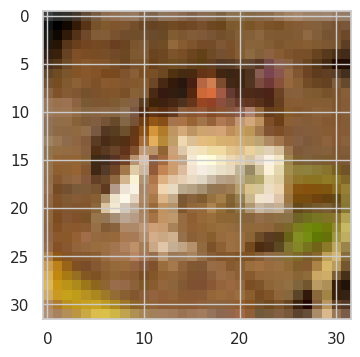

In [ ]:
# 첫번째 데이터와 이미지 확인
print('첫번째 데이터의 구조:', X_train[0].shape)
print('첫번째 데이터의 첫번째 픽셀값(RGB):', X_train[0][0][0])
print('첫번째 타겟값:', y_train[0])

plt.figure(figsize=(4,4))
plt.imshow(X_train[0])
#plt.axis('off')
plt.show()

In [ ]:
# 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

#### cnn model

In [ ]:
##############################################################################
# basic cnn
# 맥스풀링은 지나친 정보 손실을 막기 위해 보통 Conv 2개 + 1 MaxPooling 형태를 만든다.
##############################################################################

model = keras.Sequential([
    # 입력층 : 32개 feature map, 3x3 커널, 입력=출력 동일하게 제로패팅, 입력데이터 형태, 활성화함수
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.Activation('relu'),

    # 2번째 은닉층 & 맥스풀링
    layers.Conv2D(32, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # 3~4번째 은닉층 & 맥스풀링
    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same'),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),

    # 출력을 위해 3차원 -> 1차원 변환
    layers.Flatten(),

    # 학습결과
    layers.Dense(128),
    layers.Activation('relu'),

    # 학습결과 -> 최종 출력값 (0~9가 될 확률)
    layers.Dense(10),
    layers.Activation('softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,274 (2.26 MB)

 Trainable params: 591,274 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compile & training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.3860 - loss: 1.6752 - val_accuracy: 0.6348 - val_loss: 1.0336
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6651 - loss: 0.9512 - val_accuracy: 0.6785 - val_loss: 0.9054
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7395 - loss: 0.7426 - val_accuracy: 0.7092 - val_loss: 0.8357
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7874 - loss: 0.6140 - val_accuracy: 0.7394 - val_loss: 0.7595
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8255 - loss: 0.5009 - val_accuracy: 0.7573 - val_loss: 0.7201
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8622 - loss: 0.3950 - val_accuracy: 0.7440 - val_loss: 0.7981
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8888 - loss: 0.3147 - val_accuracy: 0.7455 - val_loss: 0.8624
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9164 - loss: 0.2429 - val_accuracy:

,accuracy,loss,val_accuracy,val_loss
15,0.97098,0.083742,0.7393,1.694069
16,0.97318,0.080403,0.7355,1.754727
17,0.97622,0.069766,0.7349,1.702404
18,0.97694,0.066588,0.7441,1.836065
19,0.97736,0.069379,0.7333,1.861983


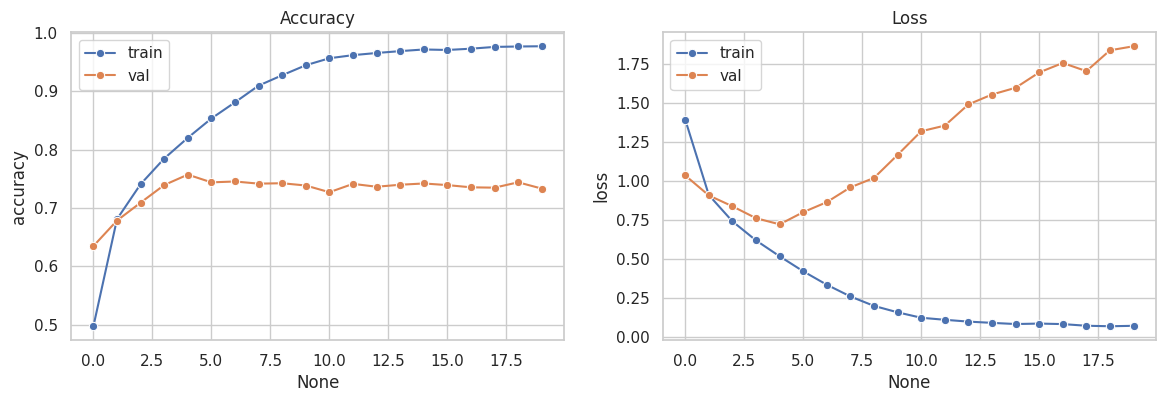

In [ ]:
# visualization
df_history = pd.DataFrame(history.history)
display(df_history.tail())

fig, axes = plt.subplots(1,2, figsize=(14,4))

sns.lineplot(data=df_history, x=df_history.index, y='accuracy', marker='o', label='train', ax=axes[0])
sns.lineplot(data=df_history, x=df_history.index, y='val_accuracy', marker='o', label='val', ax=axes[0])
axes[0].set_title('Accuracy')
axes[0].legend()

sns.lineplot(data=df_history, x=df_history.index, y='loss', marker='o', label='train', ax=axes[1])
sns.lineplot(data=df_history, x=df_history.index, y='val_loss', marker='o', label='val', ax=axes[1])
axes[1].set_title('Loss')
axes[0].legend()

plt.show()

In [ ]:
# eval
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy :", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7350 - loss: 1.8163
Accuracy : 0.733299970626831


#### 성능개선
- 데이터 증강 (ImageDataGenerator)
- 데이터 졍규화 (BatchNormalization)
- 학습효율 (EarlyStopping, ModelCheckpoint)

In [ ]:
# data re-loading, 정규화
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Data Augmentation (epoch마다 랜덤하게 이미지 변형)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,        # 이미지를 최대 ±15도 회전
    width_shift_range=0.1,    # 이미지를 좌우로 최대 10% 이동
    height_shift_range=0.1,   # 이미지를 위아래로 최대 10% 이동
    horizontal_flip=True      # 이미지를 좌우 반전
)

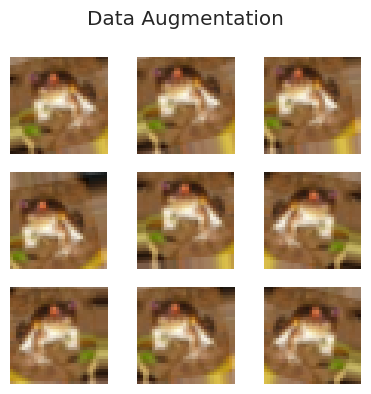

In [ ]:
## 참고. 데이터 증강 이해
img = X_train[0]

# datagen은 입력형태를 (몇장, 가로, 세로, 채널)로 받는다.
# 따라서 (32, 32, 3)  -> (1, 32, 32, 3)
img = img.reshape((1,) + img.shape)

plt.figure(figsize=(4,4))

i = 0
for batch in datagen.flow(img, batch_size=1):

    plt.subplot(3,3,i+1)
    plt.imshow(batch[0])
    plt.axis('off')

    i += 1
    if i == 9:
        break

plt.suptitle("Data Augmentation")
plt.tight_layout()
plt.show()

In [ ]:
############################################################################
# 성능개선
# 1) BatchNorm 적용  : 각 레이어의 입력층 데이터 정규화
# 2) Dropout : Overfitting 방지
############################################################################

model = keras.Sequential([

    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),


    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),


    layers.Flatten(),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,118,762 (4.27 MB)

 Trainable params: 1,117,866 (4.26 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
############################################################################
# compile (overfitting 방지, 훈련속도 개선)
# 1. EarlyStopping : epoch 5회 동안 성능개선이 없으면 훈련 중단
# 2. ModelCheckPoint : 성능이 가장 좋을 때의 모델을 파일로 저장
############################################################################

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cifar_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
# training
history = model.fit(
    # 데이터 증강(Data Augmentation) 적용한 배치 생성
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=40,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint]
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.3739 - loss: 1.8139
Epoch 1: val_loss improved from inf to 1.26728, saving model to best_cifar_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 57ms/step - accuracy: 0.3740 - loss: 1.8136 - val_accuracy: 0.5410 - val_loss: 1.2673
Epoch 2/40
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5782 - loss: 1.1856
Epoch 2: val_loss improved from 1.26728 to 0.90894, saving model to best_cifar_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5782 - loss: 1.1855 - val_accuracy: 0.6784 - val_loss: 0.9089
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6316 - loss: 1.0420
Epoch 3: val_loss did not improve from 0.90894
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.6316 - loss: 1.0420 - val_accuracy: 0.6664 - val_loss: 0.9475
Epoch 4/40
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.6643 - loss: 0.9534
Epoch 4: val_loss improved from 0.90894 to 0.88575, saving model to be

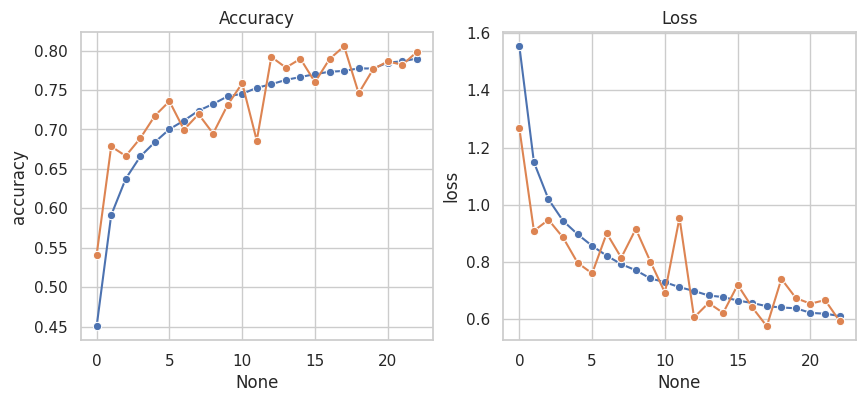

In [ ]:
# visualization
df_history = pd.DataFrame(history.history)

fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.lineplot(data=df_history, x=df_history.index, y='accuracy', marker='o', ax=axes[0])
sns.lineplot(data=df_history, x=df_history.index, y='val_accuracy', marker='o', ax=axes[0])
axes[0].set_title('Accuracy')

sns.lineplot(data=df_history, x=df_history.index, y='loss', marker='o', ax=axes[1])
sns.lineplot(data=df_history, x=df_history.index, y='val_loss', marker='o', ax=axes[1])
axes[1].set_title('Loss')

plt.show()

In [ ]:
# eval
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy :", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8084 - loss: 0.5712
Accuracy : 0.8054999709129333


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step
예측값 : 6
각 클래스에 속할 확률 : [[0.    0.    0.    0.001 0.    0.    0.999 0.    0.    0.   ]]


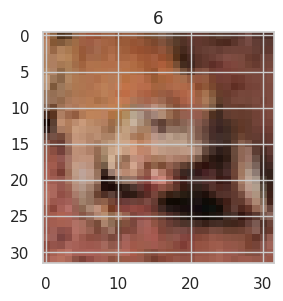

In [ ]:
# 저장된 모델 불러와 예측결과 확인
best_model = keras.models.load_model('best_cifar_model.keras')

# 예측 (주의: 모델 입력 형태 맞추기~(1, 32, 32, 3))
i = 5
j = i + 1

pred = best_model.predict(X_test[i:j])
pred_class = np.argmax(pred)

print("예측값 :", pred_class)
print("각 클래스에 속할 확률 :", np.round(pred, 3))

plt.figure(figsize=(3,3))
plt.imshow(X_test[i])
plt.title(pred_class)
#plt.axis('off')
plt.show()